In [61]:
import torch.nn as nn
import torch
import numpy as np
import pandas as pd

In [62]:
import matplotlib.pyplot as plt

In [63]:
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [64]:
def z_normalization(x: np.array):
    mean = np.mean(x, axis=0)
    std = np.std(x, axis=0)
    result = (x - mean) / (std + 1e-8)
    return result


def fancy_output(d: dict):
    for k in d:
        print(f"{k}: {d[k]:.2f}")
    return

def create_seq(x: np.array, y: np.array):
    n = 12
    horizon = 4
    result_x = []
    res_y = []
    for i in range(x.shape[0] - n - horizon):
        result_x.append(x[i:i+n, :].tolist())
        res_y.append(y[i+n+horizon])
    return np.array(result_x), np.array(res_y)

def prepare_dy(y: np.array):
    res = y
    return res


In [65]:
import os

path = r"C:\Users\User\Documents\parser\vic2-save\model\data"
directory = os.listdir(path)

In [ ]:
datasets = []

for file in directory:
    if "_1" in file:
        if file == "FRA_1.csv":
            data4 = pd.read_csv(os.path.join(path, file))
        else:
            datasets.append(pd.read_csv(os.path.join(path, file)))


gdp_plot = []
def prepare_country_data(df):
    global gdp_plot
    gdp = df["gdp"].values
    gdp_plot.extend(gdp[12+4:])
    growth = prepare_dy(gdp)
    growth = z_normalization(growth)
    bad_cols = ["date", "gdp", "gdp_per_cap", "consuption", "supply", 
                 "gdp_per_reg", "goverement", "most_popular_party", "flag_name"]
    
    for col in bad_cols:
        if col in df.columns:
            df = df.drop([col], axis=1)

    x = df.values[:]
    x_z = z_normalization(x)
    return create_seq(x_z, growth)

seq_X = []
seqs_y = []

k = 0
for df in datasets:
    x_s, y_s = prepare_country_data(df)
    #y_s = np.tanh(y_s / 2.0) * 2.0

    seq_X.append(x_s)
    seqs_y.append(y_s)

    k += 1

    
X_f = np.concatenate(seq_X, axis=0)
y_f = np.concatenate(seqs_y, axis=0)

X_val, y_val = prepare_country_data(data4)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X = torch.tensor(X_f, dtype=torch.float32)
y = torch.tensor(y_f, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X, y)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [67]:
len(gdp_plot)

1240

In [68]:
print(X.shape)
print(y.shape)
print(X_val.shape)
print(y_val.shape)

torch.Size([1116, 12, 31])
torch.Size([1116, 1])
torch.Size([124, 12, 31])
torch.Size([124, 1])


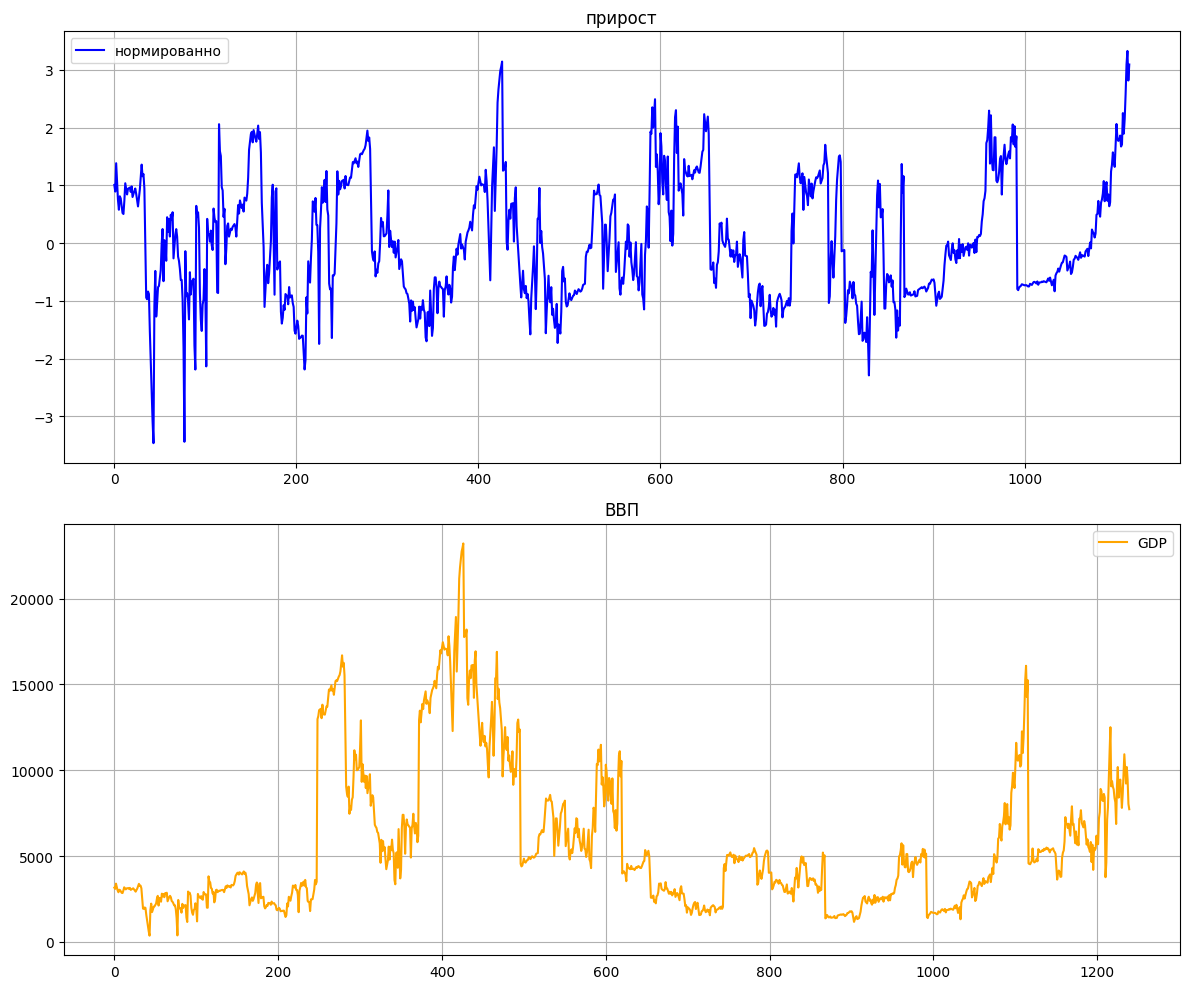

In [69]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.plot(y.numpy(), color='blue', label='нормированно')
ax1.set_title('прирост')
ax1.legend()
ax1.grid(True)


#ax2.plot(y.numpy(), color='blue', label='Прирост')
ax2.plot(gdp_plot, color='orange', label='GDP')
ax2.set_title('ВВП')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [70]:
class Model_mem(nn.Module):
    def __init__(self, input_size = 31, hidden = 8, n_l = 2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, n_l, batch_first=True, dropout=0.4)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_step = out[:, -1, :]
        return self.fc(last_step)

In [71]:
model = Model_mem().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-2)
criterion = nn.MSELoss()

n_epochs = 3000

In [72]:
print(device)

cuda


In [73]:
for epoch in range(n_epochs):
    model.train()
    total_train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        prediction = model(batch_X)
        loss = criterion(prediction, batch_y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            prediction = model(batch_X)
            loss = criterion(prediction, batch_y)
            total_val_loss += loss.item()
    if epoch % 100 == 0:
        avg_train = total_train_loss / len(train_loader)
        avg_val = total_val_loss / len(val_loader)
        print(f"Эпоха {epoch}, потери - {avg_train:.4f}, потери на валид. даных - {avg_val:.4f}")

Эпоха 0, потери - 1.0336, потери на валид. даных - 1.0007
Эпоха 100, потери - 0.1742, потери на валид. даных - 2.0623
Эпоха 200, потери - 0.1454, потери на валид. даных - 2.1907
Эпоха 300, потери - 0.1403, потери на валид. даных - 2.4569
Эпоха 400, потери - 0.1360, потери на валид. даных - 2.4875
Эпоха 500, потери - 0.1407, потери на валид. даных - 2.6252
Эпоха 600, потери - 0.1283, потери на валид. даных - 2.7335
Эпоха 700, потери - 0.1400, потери на валид. даных - 2.8689
Эпоха 800, потери - 0.1239, потери на валид. даных - 2.6640
Эпоха 900, потери - 0.1280, потери на валид. даных - 2.8943
Эпоха 1000, потери - 0.1381, потери на валид. даных - 3.0901
Эпоха 1100, потери - 0.1301, потери на валид. даных - 2.8629
Эпоха 1200, потери - 0.1359, потери на валид. даных - 2.8175
Эпоха 1300, потери - 0.1247, потери на валид. даных - 3.0769
Эпоха 1400, потери - 0.1242, потери на валид. даных - 2.8896
Эпоха 1500, потери - 0.1259, потери на валид. даных - 3.0246
Эпоха 1600, потери - 0.1153, потери 

In [80]:
gdp = datasets[2]["gdp"]
gdp = z_normalization(gdp)

X = X.to(device)

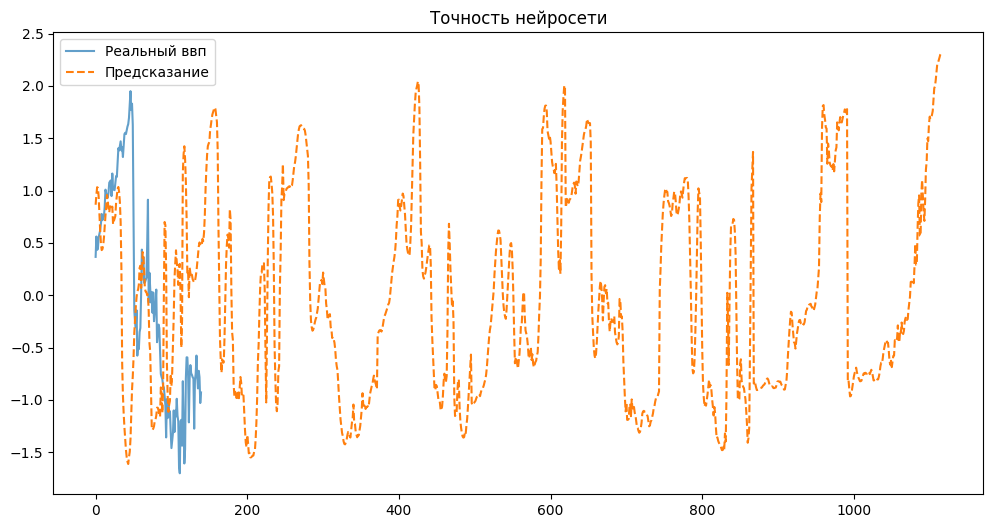

In [ ]:


model.eval()
with torch.no_grad():
    predictions = model(X).squeeze().cpu().numpy()
plt.figure(figsize=(12, 6))
plt.plot(gdp, label='Реальный ввп', alpha=0.7)
plt.plot(predictions, label='Предсказание', linestyle='--')
plt.legend()
plt.title("Точность нейросети")
plt.show()

In [82]:
data_train = pd.read_csv("data/AUS_1.csv")
y_np_t = data_train["gdp"].values
X_np_t = data_train.drop(["date", "gdp_per_cap", "consuption", "supply", "gdp_per_reg", "goverement", "most_popular_party", "flag_name"], axis=1).values

y_z_t = z_normalization(y_np_t)
X_z_t = z_normalization(X_np_t)

X_z, y_z = create_seq(X_z_t, y_z_t)

X_t = torch.tensor(X_z, dtype=torch.float32)
y_t = torch.tensor(y_z, dtype=torch.float32).view(-1, 1)


In [83]:
model.eval()
with torch.no_grad():
    predictions = model(X_t).numpy()

RuntimeError: input.size(-1) must be equal to input_size. Expected 31, got 32

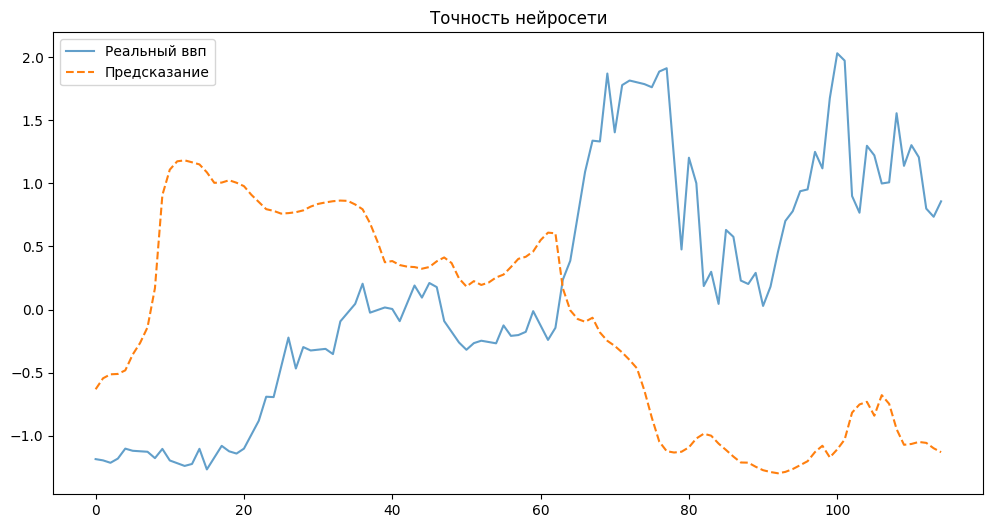

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_t.numpy(), label='Реальный ввп', alpha=0.7)
plt.plot(predictions, label='Предсказание', linestyle='--')
plt.legend()
plt.title("Точность нейросети")
plt.show()